# Podstawowe predykaty geometryczne, przeprowadzanie testów, wizualizacja i opracowanie wyników

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitalg.tests.test1 import Test
from bitalg.visualizer.main import Visualizer
import math
import random
np.random.seed(54378457)

# Przydatne funkcje 

In [2]:
def draw_points(points):
    vis = Visualizer()
    vis.add_point(points, s=0.3, color='blue')
    vis.show()

In [3]:
def draw_line(points_left, points_mid, points_right):
    vis = Visualizer()
    vis.add_line(((-1.0, 0.0), (1.0,0.1)), color='red')
    vis.add_point(points_left, s=30, color=['blue'])
    vis.add_point(points_mid, s=30, color=['yellow'])
    vis.add_point(points_right, s=30, color=['pink'])
    vis.show()

In [4]:
def draw_example():
    vis = Visualizer()
    vis.add_line(((0, 2), (10, 7)))
    vis.add_point((4, 4), s=30, color='blue')
    vis.add_point((6, 6), s=30, color='red')
    vis.add_point((7, 4), s=30, color='yellow')
    vis.show()

### Wprowadzenie
Celem ćwiczenia jest określenie po której stronie prostej znajduje się punkt.

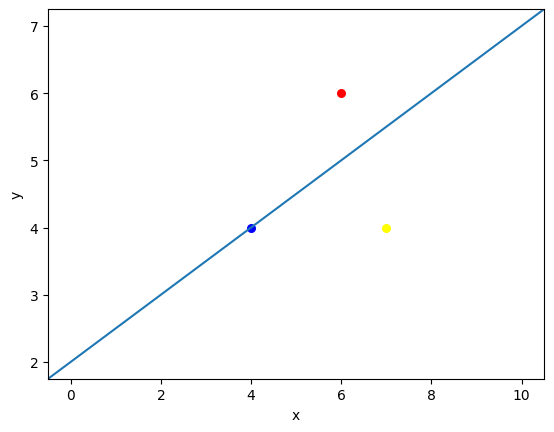

In [5]:
draw_example()

Do tego celu potrzebujesz wygenerować zbiory punktów testowych.


# Generowanie losowych punktów na płaszczyźnie

Uzupełnij funkcję ```generate_uniform_points```
 (Aby generować losowo liczby rzeczywiste bardzo przydatna może okazać się jakaś funckja biblioteczna)

In [6]:
def generate_uniform_points(left, right, n = 10 ** 5):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym obszarze od left do right (jednakowo na osi y) o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    points = [(random.uniform(left, right), random.uniform(left, right)) for _ in range(n)]
    return points

<span style="color:red">Ćw.</span> Wygeneruj $10^5$ losowych punktów w przestrzeni 2D o współrzędnych z przedziału $x, y \in \left[-1000,1000\right]^{2}$.

In [7]:
points_a = generate_uniform_points(-1000, 1000, 10 ** 5)

Zwizualizuj wygenerowane punkty

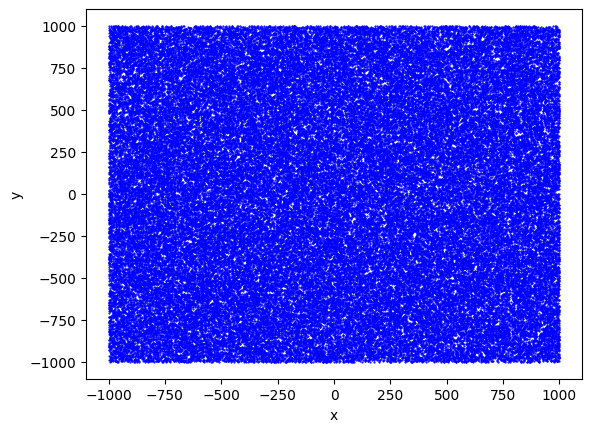

In [8]:
draw_points(points_a)

<span style="color:red">Ćw.</span> Wygeneruj $10^5$ losowych punktów w przestrzeni 2D o współrzędnych z przedziału $ x, y \in \left[-10^{14},10^{14}\right]^{2}$. Uzupełnij funkcję ```generate_big_num_of_points_2D```. Sprawdź, czy różni się wizualizalnie wynik tego ćwiczenia z poprzednim.

In [9]:
points_b = generate_uniform_points(-10 ** 14, 10 ** 14, 10 ** 5)

Zwizualizuj wygenerowane punkty.

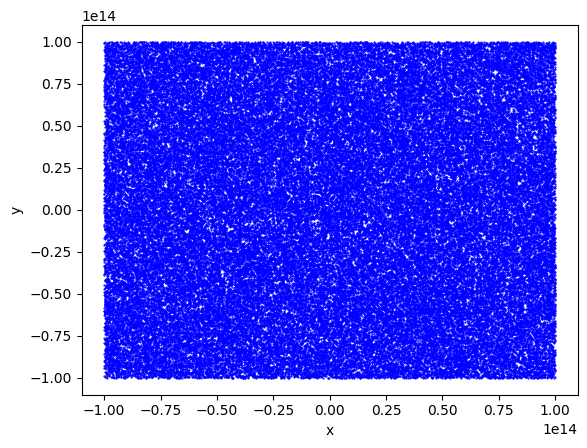

In [10]:
draw_points(points_b)

Uzupełnij funkcję ```generate_circle_points```

Zastanów się w sposób generować punkty jednostajnie na okręgu.

In [11]:
def generate_circle_points(O, R, n = 100):
    """
    Funkcja generuje jednostajnie n punktów na okręgu o środku O i promieniu R
    :param O: krotka współrzędnych x, y określająca środek okręgu
    :param R: promień okręgu 
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    ox, oy = O
    points = []
    for i in range(n):
        angle = 2 * math.pi * i / n  # równy podział kąta
        x = ox + R * math.cos(angle)
        y = oy + R * math.sin(angle)
        points.append((x, y))
    return points

<span style="color:red">Ćw.</span> Wygeneruj $ 1000$ losowych punktów w przestrzeni 2D leżących na okręgu o środku $ O = (0,0)$ i promieniu $ R = 100$. 

Uzupełnij funkcję ```generate_points_on_circle_2D```.

In [12]:
points_c = generate_circle_points((0, 0), 100)

Zwizualizuj wygenerowane punkty.

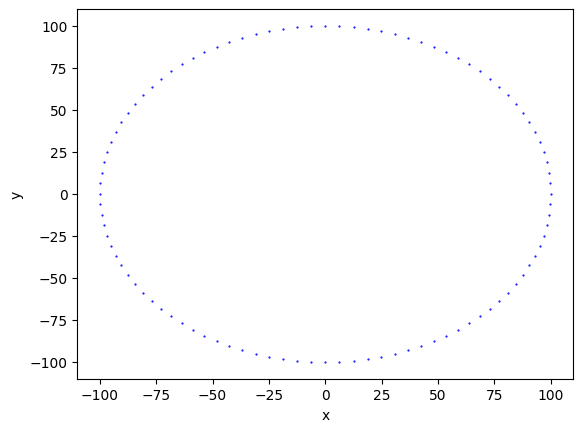

In [13]:
draw_points(points_c)

Uzupełnij funkcję ```generate_collinear_points```.

In [14]:
def generate_collinear_points(a, b, n=100):
    """
    Funkcja generuje równomiernie n współliniowych punktów leżących na prostej ab pomiędzy punktami a i b
    :param a: krotka współrzędnych oznaczająca początek wektora tworzącego prostą
    :param b: krotka współrzędnych oznaczająca koniec wektora tworzącego prostą
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    ax, ay = a
    bx, by = b
    points = []
    for i in range(n):
        t = i / (n - 1)   # równomierny podział przedziału [0,1]
        x = (1 - t) * ax + t * bx
        y = (1 - t) * ay + t * by
        points.append((x, y))
    return points

<span style="color:red">Ćw.</span>  Wygeneruj $ 1000$ losowych punktów w przestrzeni 2D o współrzędnej z przedziału $ x \in \langle -1000,1000 \rangle$ leżących na prostej wyznaczonej przez wektor $ \overrightarrow{ab}$. Przyjmij punkty $ a = (-1.0, 0.0)$ oraz $ b = (1.0, 0.1)$. Uzupełnij funkcję ```generate_points_on_line_2D```.

In [15]:
points_d= generate_collinear_points((-1.0, 0.0), (1.0,0.1))

Zwizualizuj wygenerowane punkty.

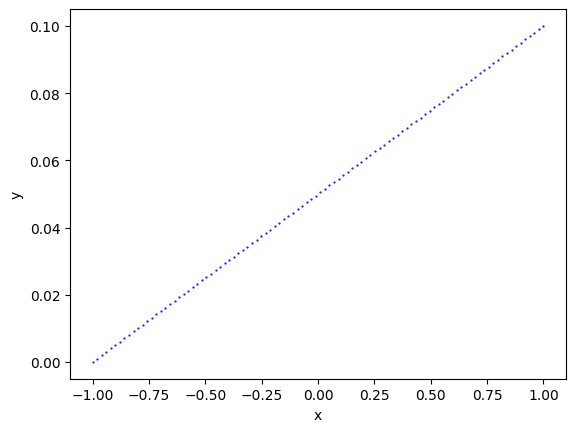

In [16]:
draw_points(points_d)

Przeprowadź test poprawności powyższych funkcji

In [17]:
Test().runtest(1, generate_uniform_points, generate_circle_points, generate_collinear_points)

Lab 1, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
Result: 4/4
Time: 0.102s


# Po której stornie prostej znajduje się punkt?

Prostym sposobem do obliczenia, po której strnie prostej znajduje się punkt jest obliczenie iloczynu wektorowego 
$\overrightarrow{ab} \times \overrightarrow{ac}$, gdzie $ c = (x,y)$ jest punktem, dla którego poszukujemy wiadomości o lokalizacji względem prostej przechodzącej przez punkty $ a$ i $ b$. Metoda ta jest równoznaczna z obliczeniem wyznacznika macierzy $ 2\times2$:  

$$
(1)\det(a, b, c)= \begin{vmatrix}
       a_{x} - c_{x} & a_{y} - c_{y} \\
       b_{x} - c_{x} & b_{y} - c_{y} 
              \end{vmatrix}
$$


lub wyznacznika macierzy $ 3\times3$:

$$
(2)\det(a, b, c)= \begin{vmatrix}
       a_{x} & a_{y} & 1 \\
       b_{x} & b_{y} & 1 \\
       c_{x} & c_{y} & 1
              \end{vmatrix}
$$

Upraszczając tą macierz przez odjęcie drugiego wiersza od trzeciego i odjęcie pierwszego wiersza od drugiego otrzymamy:

$$
\det(a, b, c)  = \begin{vmatrix}
              a_{x}         & a_{y}         & 1 \\
              b_{x} - a_{x} & b_{y} - a_{y} & 0 \\
              c_{x} - b_{x} & c_{y} - b_{y} & 0
                     \end{vmatrix}
              = (b_{x} - a_{x})(c_{y} - b_{y}) - (b_{y} - a_{y})(c_{x} - b_{x})
$$

Jest to wzór, z który opisuje pole równoległoboku mającego boki $ ab$ oraz $ ac$ (Dowód dlaczego tak jest, do zrobienia w domu)  
Dlaczego wiemy, że po obliczeniu wskaźnika podanego powyżej będziemy wiedzieć, po której stornie prostej znajduje się punkt?</font>
<font size="1">
</br>
***

**Dowód**:  

Załóżmy, że mamy dane trzy punkty w przestrzeni 2-wymiarowej $A, B$ oraz $C$. Znajdujemy prostą przechodzącą przez punkty $A$ i $B$. Następnie obliczamy $C_{y}$ przy danym $C_{x}$ i sprawdzamy czy punkt leży nad czy pod prostą.
Współczynnik nachylenia prostej jest nastepujący:

$$a = \frac{B_{y} - A_{y}}{B_{x} - A_{x}}
$$
Natomiast współczynnik $b$ wynosi:

$$b = B_{y} - \frac{(B_{y} - A_{y})B_{x}}{B_{x} - A_{x}}
$$

Po wpisaniu do równania $y = ax + b$ wyliczonego nachylenia prostej, współczynnika $b$ oraz zmiennej $C_{x}$ otrzymujemy:

$$y = \left(\frac{B_{y} - A_{y}}{B_{x} - A_{x}}\right)C_{x}+ \left(B_{y} - \frac{(B_{y} - A_{y})B_{x}}{B_{x} - A_{x}}\right)
$$

Otzymujemy punkt $C$ po lewej stronie prostej jeżeli $C_{y} - y > 0$, po prawej jeżeli $C_{y} - y < 0$, a punkt $C$ leżący na prostej, jeżeli $C_{y} - y = 0$. Przekształcimy powyższe równanie dla $C_{y} - y > 0$:

$$C_{y} - y > 0$$ 
$$C_{y} - \left(\frac{B_{y} - A_{y}}{B_{x} - A_{x}}\right)C_{x} - \left(B_{y} - \frac{(B_{y} - A_{y})B_{x}}{B_{x} - A_{x}}\right) > 0$$
$$C_{y}(B_{x} - A_{x}) - C_{x}(B_{y} - A_{y}) - B_{y}(B_{x} - A_{x}) + B_{x}(B_{y} - A_{y}) > 0$$
$$(C_{y} - B_{y})(B_{x} - A_{x}) + (B_{x} - C_{x})(B_{y} - A_{y}) > 0$$ 
$$(C_{y} - B_{y})(B_{x} - A_{x}) - (C_{x} - B_{x})(B_{y} - A_{y}) > 0$$

Zatem widzimy, że ostatnie równie jest takie same co przy równaniu wyznacznika macierzy $3\times3$. Niejawnie założyliśmy tutaj, że $B_{x}$ jest wieksze od $A_{x}$ , jeżeli byłoby odwrotnie zmieniłby się tylko znak nierówności na przeciwny. W naszym przypadku pokazaliśmy, że $C$ znajduje się po lewej stronie prostej jeżeli wyznacznik jest dodatni oraz po prawej stronie prostej, jeżeli wyznacznik jest ujemny. $Q.E.D$

---
Kolejnym zadaniem będzie zaimplementowanie własnych wyznaczników $(1)$ oraz $(2)$ i porówanie ich szybkości działania z wyznacznikami bibliotecznymi w testowaniu dla różnych zbiorów punktów. Co dodatkowo chcemy sprawdzić, czy wszystkie wyznaczniki podobnie kwalifikują podział względem danej lini.

Uzupełnij funkcje ```mat_det_3x3```

In [18]:
def mat_det_3x3(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    xa, ya = a
    xb, yb = b
    xc, yc = c

    det = (xa * yb * 1 + ya * 1 * xc + 1 * xb * yc) - (1 * yb * xc + ya * xb * 1 + xa * 1 * yc)
    return det

Uzupełnij funkcję ```mat_det_3x3_lib```, ale tym razem wykorzystaj dowolną funckję biblioteczną do obliczenia wyznacznika

In [19]:
def mat_det_3x3_lib(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 z użyciem funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    xa, ya = a
    xb, yb = b
    xc, yc = c
    
    M = np.array([
        [xa, ya, 1],
        [xb, yb, 1],
        [xc, yc, 1]
    ])
    
    det = np.linalg.det(M)
    return det

Uzupełnij funkcje ```mat_det_2x2```

In [20]:
def mat_det_2x2(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    xa, ya = a
    xb, yb = b
    xc, yc = c

    return (xa - xc) * (yb - yc) - (ya - yc) * (xb - xc)

Uzupełnij funkcję ```mat_det_2x2_lib```, ale tym razem wykorzystaj dowolną funckję biblioteczną do obliczenia wyznacznika

In [21]:
def mat_det_2x2_lib(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 z użyciem funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    xa, ya = a
    xb, yb = b
    xc, yc = c

    M = np.array([
        [xa - xc, ya - yc],
        [xb - xc, yb - yc]
    ])

    det = np.linalg.det(M)
    return det

Przetestujmy napisane powyżej funkcje.

In [22]:
Test().runtest(2, mat_det_3x3, mat_det_2x2, mat_det_3x3_lib, mat_det_2x2_lib)

Lab 1, task 2:
	Test 1: Passed
	Test 2: Passed
Result: 2/2
Time: 0.001s


<span style="color:red">Ćw.</span> Klasyfikacja punktów względem prostej - zaimplementuj funkcję ```categorize_points```, która skwalifukuje punkty względem prostej wyznacznonej przez wektor $\large \overrightarrow{ab}$ (prosta przechodząca przez punkty $\large a$ oraz $\large b$.

In [23]:
def categorize_points(points, a, b, mat_det_func, eps):
    """
    :param points: tablica punktów w postaci krotek współrzednych
    :param a: krotka współrzędnych oznaczająca początek odcinka
    :param b: krotka współrzędnych oznaczająca koniec odcinka
    :param mat_det_func: funkcja która będzie tutaj używana do obliczenia wyznacznika macierzy
    :param eps: epsilon - jak blisko wyznacznik macierzy ma być blisko zera, aby uznać punkt za leżący na prostej
    :return: 3 tablice zawierające kolejno zbiory punktów: leżące na lewo od prostej, leżące na prostej, leżące na prawo od prostek
    """
    left = []
    on_line = []
    right = []

    for p in points:
        det = mat_det_func(a, b, p)
        if det > eps:
            left.append(p)
        elif det < -eps:
            right.append(p)
        else:
            on_line.append(p)

    return left, on_line, right

In [24]:
a = (-1.0, 0.0)
b = (1.0, 0.1)

Zwizualizuj sklasyfikowane punkty. Punkty różnią się kolorami ze względu na klasyfikację: na lewo od prostej - zielone, na prostej - fioletowe, na prawo - pomarańczowe.

In [25]:
classified_points_a_left,classified_points_a_mid,classified_points_a_right = categorize_points(points_a, a, b, mat_det_3x3, 10 ** -12)

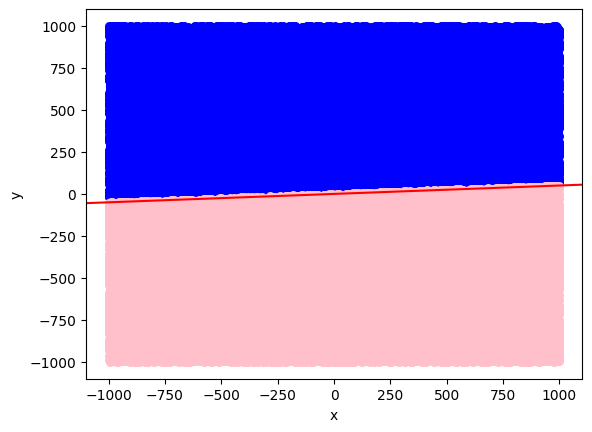

In [26]:
draw_line(classified_points_a_left, classified_points_a_mid, classified_points_a_right)

In [27]:
classified_points_b_left,classified_points_b_mid,classified_points_b_right = categorize_points(points_b, a, b, mat_det_3x3_lib, 10 ** -12)

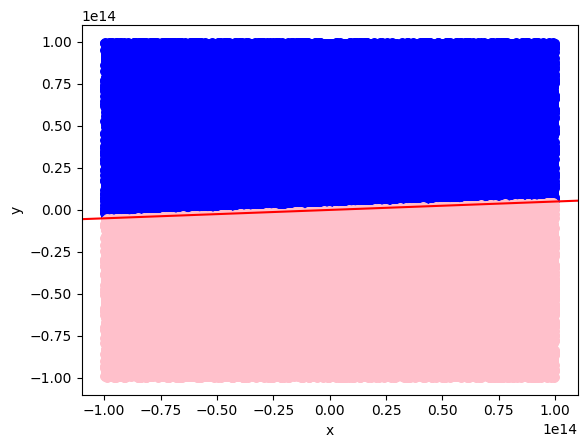

In [28]:
draw_line(classified_points_b_left, classified_points_b_mid, classified_points_b_right)

In [29]:
classified_points_c_left,classified_points_c_mid,classified_points_c_right = categorize_points(points_c, a, b, mat_det_2x2, 10 ** -12)

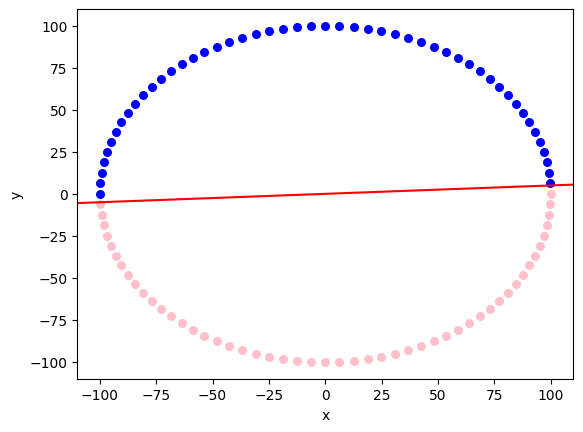

In [30]:
draw_line(classified_points_c_left, classified_points_c_mid, classified_points_c_right)

In [31]:
classified_points_d_left,classified_points_d_mid,classified_points_d_right = categorize_points(points_d, a, b, mat_det_2x2_lib, 10 ** -12)

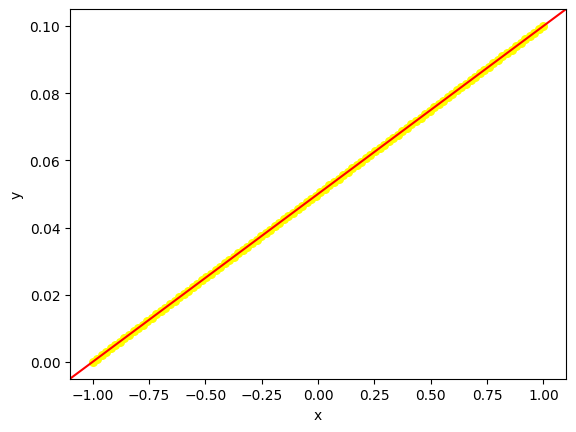

In [32]:
draw_line(classified_points_d_left, classified_points_d_mid, classified_points_d_right)

Przeprowadźmy teraz testy dla mniejszej precyzji obliczeń. Do tego celu należy zmiejszyć typ danych z float64 (domyślny typ floata w pythonie) na float32. Różnią się one tym, że float32 jest zapisywane na mniejszej ilości bitów, co przekłada się no mniejszą ilosć cyfr po przecinku.
Zamienić typ floata w całej tablicy można zrobić w następujący sposób:

In [33]:
points_a_float32 = np.float32(points_a)
points_b_float32 = np.float32(points_b)
points_c_float32 = np.float32(points_c)
points_d_float32 = np.float32(points_d)

Porównaj wyniki klasyfikacji dla współrzędnych punktów o zmiejszonej precyzji floata

## Opisz swoje wnioski na podstawie przeprowadzonych własnoręcznie testów.


In [34]:
epsilons = [0, 1e-7, 1e-10, 1e-11, 1e-14]
det_functions = [mat_det_2x2_lib, mat_det_2x2, mat_det_3x3_lib, mat_det_3x3]

In [35]:
def categorize(points, a, b, epsilons, det_funcs):
    rows = []

    for eps in epsilons:
        for func in det_funcs:
            left, on_line, right = categorize_points(points, a, b, func, eps)
            rows.append({
                "eps": eps,
                "det_func": func.__name__,
                "left": len(left),
                "on_line": len(on_line),
                "right": len(right)
            })

    return pd.DataFrame(rows)

In [38]:
def get_points_on_line(points, a, b, epsilons, det_func):
    points_on_line = {}

    for eps in epsilons:
        _, on_line, _ = categorize_points(points, a, b, det_func, eps)
        points_on_line[eps] = on_line

    return points_on_line

In [39]:
print(categorize(points_a, a, b, epsilons, det_functions))

             eps         det_func   left  on_line  right
0   0.000000e+00  mat_det_2x2_lib  50138        0  49862
1   0.000000e+00      mat_det_2x2  50138        0  49862
2   0.000000e+00  mat_det_3x3_lib  50138        0  49862
3   0.000000e+00      mat_det_3x3  50138        0  49862
4   1.000000e-07  mat_det_2x2_lib  50138        0  49862
5   1.000000e-07      mat_det_2x2  50138        0  49862
6   1.000000e-07  mat_det_3x3_lib  50138        0  49862
7   1.000000e-07      mat_det_3x3  50138        0  49862
8   1.000000e-10  mat_det_2x2_lib  50138        0  49862
9   1.000000e-10      mat_det_2x2  50138        0  49862
10  1.000000e-10  mat_det_3x3_lib  50138        0  49862
11  1.000000e-10      mat_det_3x3  50138        0  49862
12  1.000000e-11  mat_det_2x2_lib  50138        0  49862
13  1.000000e-11      mat_det_2x2  50138        0  49862
14  1.000000e-11  mat_det_3x3_lib  50138        0  49862
15  1.000000e-11      mat_det_3x3  50138        0  49862
16  1.000000e-14  mat_det_2x2_l

In [46]:
print(categorize(points_a_float32, a, b, epsilons, det_functions))

             eps         det_func   left  on_line  right
0   0.000000e+00  mat_det_2x2_lib  50072        0  49928
1   0.000000e+00      mat_det_2x2  50072        0  49928
2   0.000000e+00  mat_det_3x3_lib  50072        0  49928
3   0.000000e+00      mat_det_3x3  50072        0  49928
4   1.000000e-07  mat_det_2x2_lib  50072        0  49928
5   1.000000e-07      mat_det_2x2  50072        0  49928
6   1.000000e-07  mat_det_3x3_lib  50072        0  49928
7   1.000000e-07      mat_det_3x3  50072        0  49928
8   1.000000e-10  mat_det_2x2_lib  50072        0  49928
9   1.000000e-10      mat_det_2x2  50072        0  49928
10  1.000000e-10  mat_det_3x3_lib  50072        0  49928
11  1.000000e-10      mat_det_3x3  50072        0  49928
12  1.000000e-11  mat_det_2x2_lib  50072        0  49928
13  1.000000e-11      mat_det_2x2  50072        0  49928
14  1.000000e-11  mat_det_3x3_lib  50072        0  49928
15  1.000000e-11      mat_det_3x3  50072        0  49928
16  1.000000e-14  mat_det_2x2_l

In [53]:
print(categorize(points_b, a, b, epsilons, det_functions))

             eps         det_func   left  on_line  right
0   0.000000e+00  mat_det_2x2_lib  49827        0  50173
1   0.000000e+00      mat_det_2x2  49823        6  50171
2   0.000000e+00  mat_det_3x3_lib  49823        0  50177
3   0.000000e+00      mat_det_3x3  49823        0  50177
4   1.000000e-07  mat_det_2x2_lib  49827        0  50173
5   1.000000e-07      mat_det_2x2  49823        6  50171
6   1.000000e-07  mat_det_3x3_lib  49823        0  50177
7   1.000000e-07      mat_det_3x3  49823        0  50177
8   1.000000e-10  mat_det_2x2_lib  49827        0  50173
9   1.000000e-10      mat_det_2x2  49823        6  50171
10  1.000000e-10  mat_det_3x3_lib  49823        0  50177
11  1.000000e-10      mat_det_3x3  49823        0  50177
12  1.000000e-11  mat_det_2x2_lib  49827        0  50173
13  1.000000e-11      mat_det_2x2  49823        6  50171
14  1.000000e-11  mat_det_3x3_lib  49823        0  50177
15  1.000000e-11      mat_det_3x3  49823        0  50177
16  1.000000e-14  mat_det_2x2_l

In [55]:
print(categorize(points_b_float32, a, b, epsilons, det_functions))

             eps         det_func   left  on_line  right
0   0.000000e+00  mat_det_2x2_lib   6578    86766   6656
1   0.000000e+00      mat_det_2x2      0   100000      0
2   0.000000e+00  mat_det_3x3_lib  49823        0  50177
3   0.000000e+00      mat_det_3x3  49823        0  50177
4   1.000000e-07  mat_det_2x2_lib   6578    86766   6656
5   1.000000e-07      mat_det_2x2      0   100000      0
6   1.000000e-07  mat_det_3x3_lib  49823        0  50177
7   1.000000e-07      mat_det_3x3  49823        0  50177
8   1.000000e-10  mat_det_2x2_lib   6578    86766   6656
9   1.000000e-10      mat_det_2x2      0   100000      0
10  1.000000e-10  mat_det_3x3_lib  49823        0  50177
11  1.000000e-10      mat_det_3x3  49823        0  50177
12  1.000000e-11  mat_det_2x2_lib   6578    86766   6656
13  1.000000e-11      mat_det_2x2      0   100000      0
14  1.000000e-11  mat_det_3x3_lib  49823        0  50177
15  1.000000e-11      mat_det_3x3  49823        0  50177
16  1.000000e-14  mat_det_2x2_l

In [72]:
print(get_points_on_line(points_b, a, b, epsilons, mat_det_2x2))

{0: [(-79789978126042.61, -3999246401535.1562), (-72800652767006.0, -3644015556011.0156), (-70187697505390.445, -3510880026021.5156), (-82930901845127.95, -4171096237726.297), (-66480047073082.66, -3324200862008.4688), (99016903068999.38, 4932676395467.234)], 1e-07: [(-79789978126042.61, -3999246401535.1562), (-72800652767006.0, -3644015556011.0156), (-70187697505390.445, -3510880026021.5156), (-82930901845127.95, -4171096237726.297), (-66480047073082.66, -3324200862008.4688), (99016903068999.38, 4932676395467.234)], 1e-10: [(-79789978126042.61, -3999246401535.1562), (-72800652767006.0, -3644015556011.0156), (-70187697505390.445, -3510880026021.5156), (-82930901845127.95, -4171096237726.297), (-66480047073082.66, -3324200862008.4688), (99016903068999.38, 4932676395467.234)], 1e-11: [(-79789978126042.61, -3999246401535.1562), (-72800652767006.0, -3644015556011.0156), (-70187697505390.445, -3510880026021.5156), (-82930901845127.95, -4171096237726.297), (-66480047073082.66, -3324200862008

In [55]:
print(categorize(points_c, a, b, epsilons, det_functions))

             eps         det_func  left  on_line  right
0   0.000000e+00  mat_det_2x2_lib    50        0     50
1   0.000000e+00      mat_det_2x2    50        0     50
2   0.000000e+00  mat_det_3x3_lib    50        0     50
3   0.000000e+00      mat_det_3x3    50        0     50
4   1.000000e-07  mat_det_2x2_lib    50        0     50
5   1.000000e-07      mat_det_2x2    50        0     50
6   1.000000e-07  mat_det_3x3_lib    50        0     50
7   1.000000e-07      mat_det_3x3    50        0     50
8   1.000000e-10  mat_det_2x2_lib    50        0     50
9   1.000000e-10      mat_det_2x2    50        0     50
10  1.000000e-10  mat_det_3x3_lib    50        0     50
11  1.000000e-10      mat_det_3x3    50        0     50
12  1.000000e-11  mat_det_2x2_lib    50        0     50
13  1.000000e-11      mat_det_2x2    50        0     50
14  1.000000e-11  mat_det_3x3_lib    50        0     50
15  1.000000e-11      mat_det_3x3    50        0     50
16  1.000000e-14  mat_det_2x2_lib    50        0

In [57]:
print(categorize(points_c_float32, a, b, epsilons, det_functions))

             eps         det_func  left  on_line  right
0   0.000000e+00  mat_det_2x2_lib    50        0     50
1   0.000000e+00      mat_det_2x2    50        0     50
2   0.000000e+00  mat_det_3x3_lib    50        0     50
3   0.000000e+00      mat_det_3x3    50        0     50
4   1.000000e-07  mat_det_2x2_lib    50        0     50
5   1.000000e-07      mat_det_2x2    50        0     50
6   1.000000e-07  mat_det_3x3_lib    50        0     50
7   1.000000e-07      mat_det_3x3    50        0     50
8   1.000000e-10  mat_det_2x2_lib    50        0     50
9   1.000000e-10      mat_det_2x2    50        0     50
10  1.000000e-10  mat_det_3x3_lib    50        0     50
11  1.000000e-10      mat_det_3x3    50        0     50
12  1.000000e-11  mat_det_2x2_lib    50        0     50
13  1.000000e-11      mat_det_2x2    50        0     50
14  1.000000e-11  mat_det_3x3_lib    50        0     50
15  1.000000e-11      mat_det_3x3    50        0     50
16  1.000000e-14  mat_det_2x2_lib    50        0

In [76]:
print(categorize(points_d, a, b, epsilons, det_functions))

             eps         det_func  left  on_line  right
0   0.000000e+00  mat_det_2x2_lib    50        2     48
1   0.000000e+00      mat_det_2x2    38       23     39
2   0.000000e+00  mat_det_3x3_lib    43       46     11
3   0.000000e+00      mat_det_3x3    25       52     23
4   1.000000e-07  mat_det_2x2_lib     0      100      0
5   1.000000e-07      mat_det_2x2     0      100      0
6   1.000000e-07  mat_det_3x3_lib     0      100      0
7   1.000000e-07      mat_det_3x3     0      100      0
8   1.000000e-10  mat_det_2x2_lib     0      100      0
9   1.000000e-10      mat_det_2x2     0      100      0
10  1.000000e-10  mat_det_3x3_lib     0      100      0
11  1.000000e-10      mat_det_3x3     0      100      0
12  1.000000e-11  mat_det_2x2_lib     0      100      0
13  1.000000e-11      mat_det_2x2     0      100      0
14  1.000000e-11  mat_det_3x3_lib     0      100      0
15  1.000000e-11      mat_det_3x3     0      100      0
16  1.000000e-14  mat_det_2x2_lib     0      100

In [77]:
print(categorize(points_d_float32, a, b, epsilons, det_functions))

             eps         det_func  left  on_line  right
0   0.000000e+00  mat_det_2x2_lib    36        2     62
1   0.000000e+00      mat_det_2x2    25       27     48
2   0.000000e+00  mat_det_3x3_lib    41       17     42
3   0.000000e+00      mat_det_3x3    10       56     34
4   1.000000e-07  mat_det_2x2_lib     0      100      0
5   1.000000e-07      mat_det_2x2     0      100      0
6   1.000000e-07  mat_det_3x3_lib     0      100      0
7   1.000000e-07      mat_det_3x3     0      100      0
8   1.000000e-10  mat_det_2x2_lib    36        3     61
9   1.000000e-10      mat_det_2x2    25       27     48
10  1.000000e-10  mat_det_3x3_lib    41       17     42
11  1.000000e-10      mat_det_3x3    10       56     34
12  1.000000e-11  mat_det_2x2_lib    36        2     62
13  1.000000e-11      mat_det_2x2    25       27     48
14  1.000000e-11  mat_det_3x3_lib    41       17     42
15  1.000000e-11      mat_det_3x3    10       56     34
16  1.000000e-14  mat_det_2x2_lib    36        2

In [37]:
import matplotlib.pyplot as plt

def draw(points, a, b, epsilons, det_funcs):
    for eps in epsilons:
        for func in det_funcs:
            left, mid, right = categorize_points(points, a, b, func, eps)

            plt.figure(figsize=(5,5))
            draw_line(left, mid, right)
            plt.title(f"function: {func.__name__}, eps={eps}, float32")
            plt.show()

<Figure size 500x500 with 0 Axes>

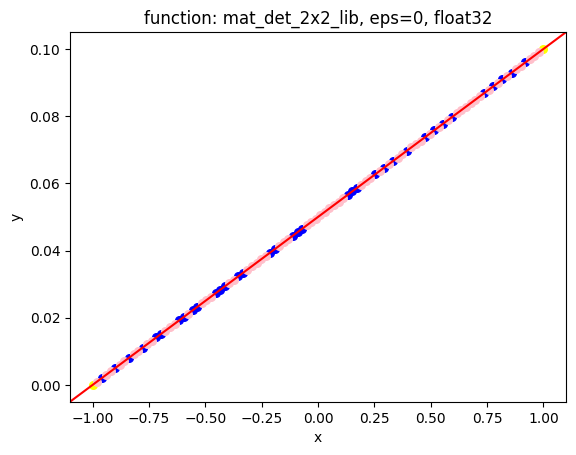

<Figure size 500x500 with 0 Axes>

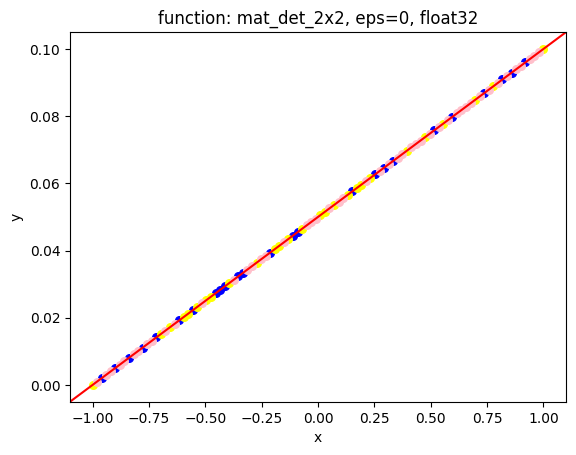

<Figure size 500x500 with 0 Axes>

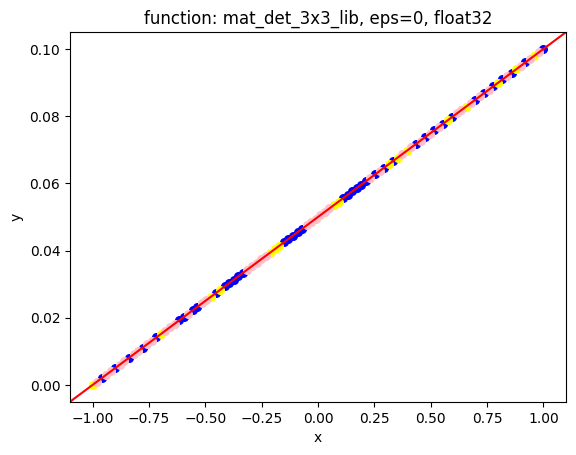

<Figure size 500x500 with 0 Axes>

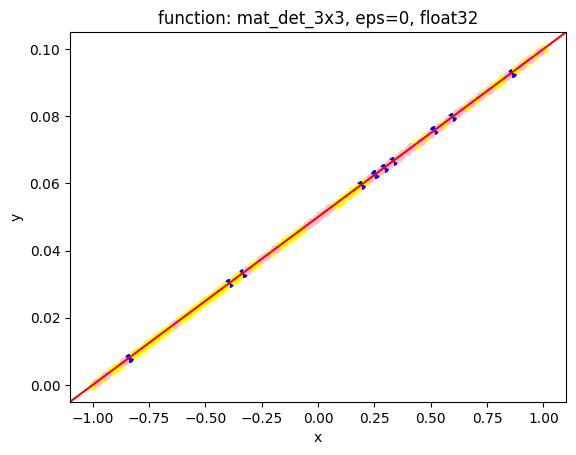

<Figure size 500x500 with 0 Axes>

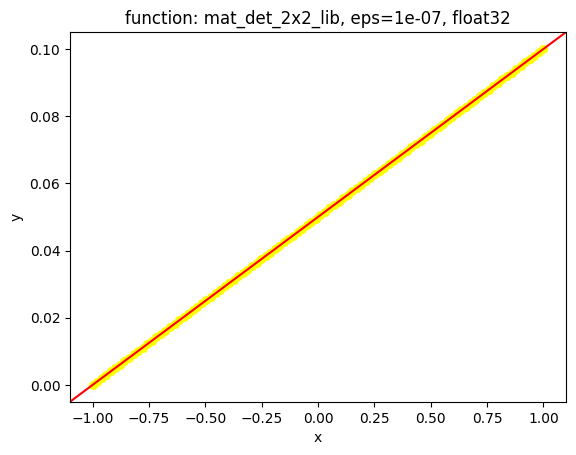

<Figure size 500x500 with 0 Axes>

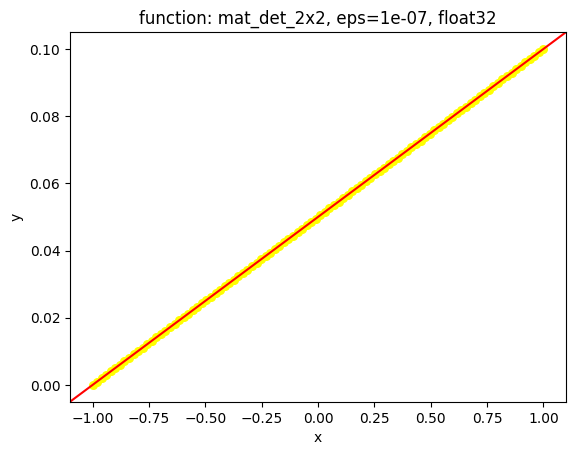

<Figure size 500x500 with 0 Axes>

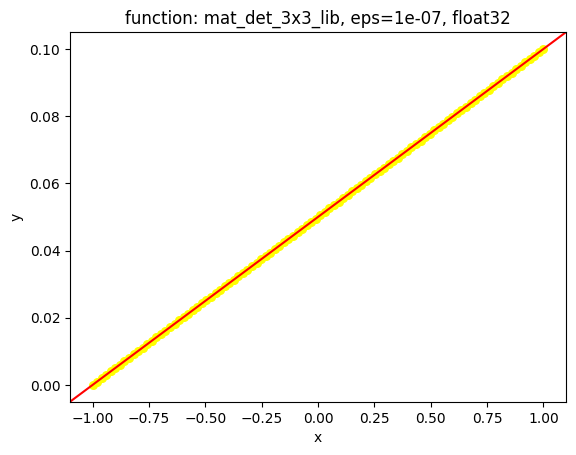

<Figure size 500x500 with 0 Axes>

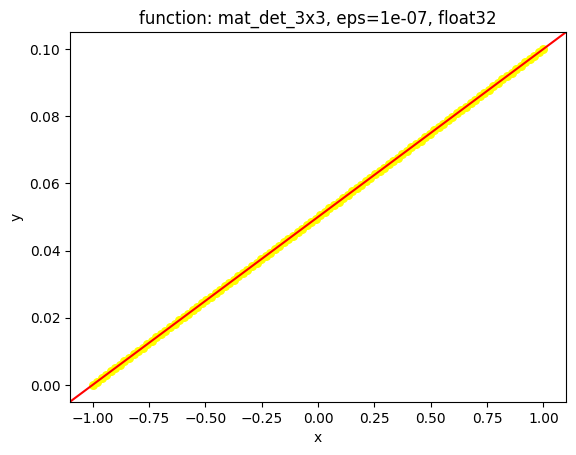

<Figure size 500x500 with 0 Axes>

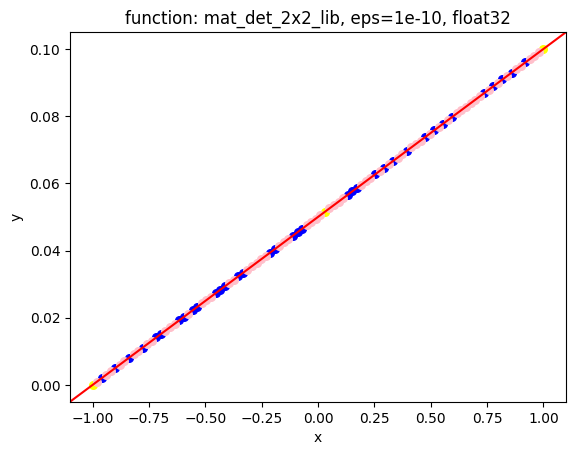

<Figure size 500x500 with 0 Axes>

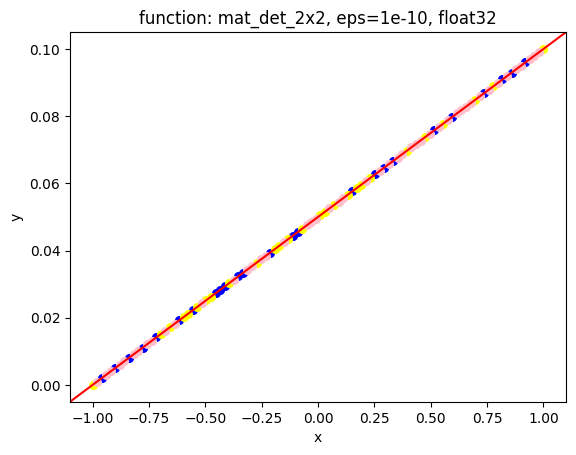

<Figure size 500x500 with 0 Axes>

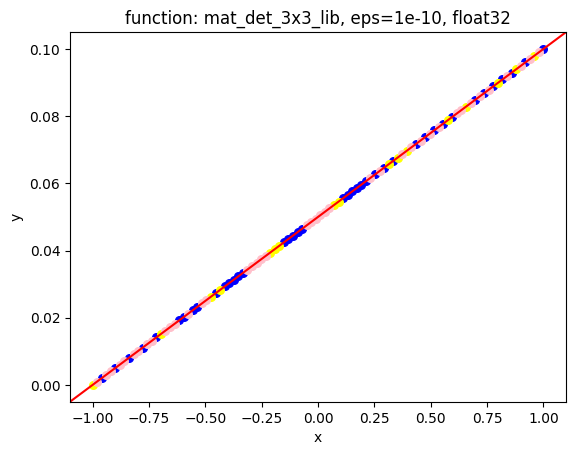

<Figure size 500x500 with 0 Axes>

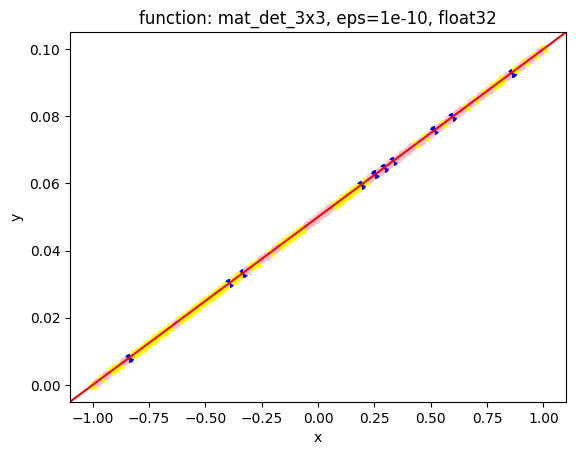

<Figure size 500x500 with 0 Axes>

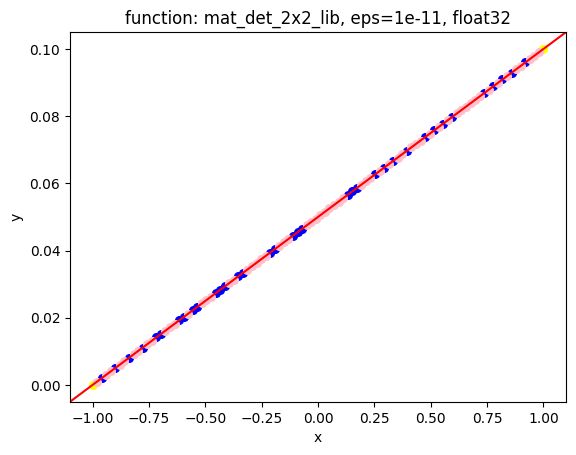

<Figure size 500x500 with 0 Axes>

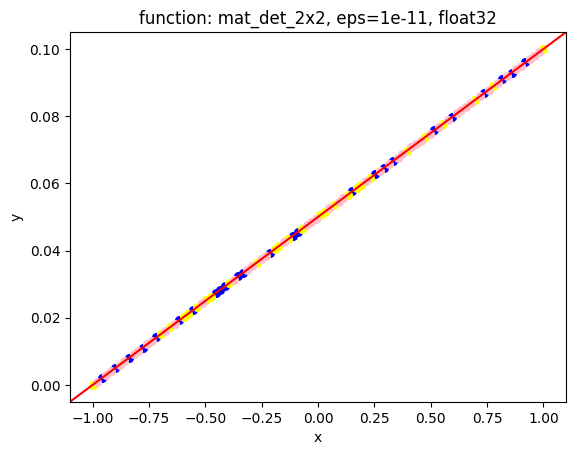

<Figure size 500x500 with 0 Axes>

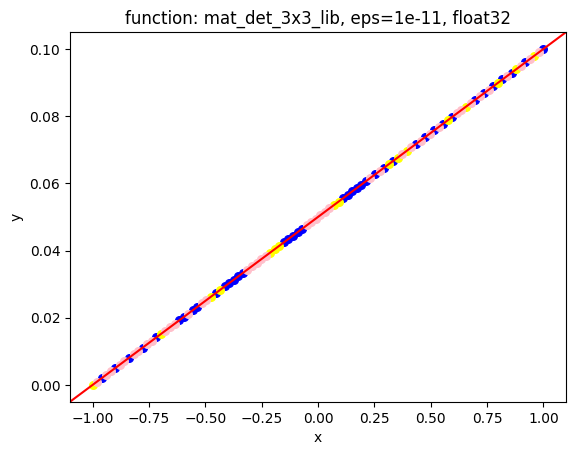

<Figure size 500x500 with 0 Axes>

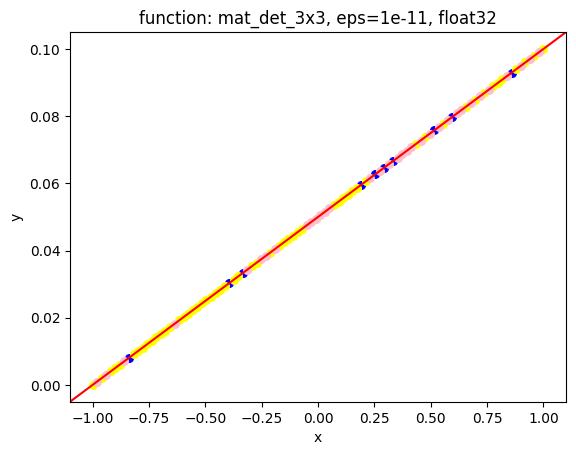

<Figure size 500x500 with 0 Axes>

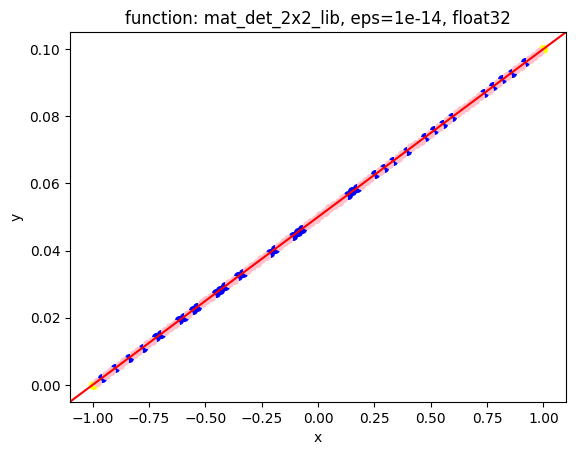

<Figure size 500x500 with 0 Axes>

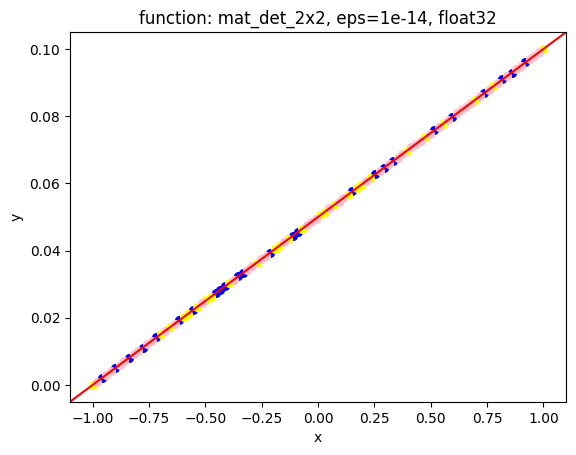

<Figure size 500x500 with 0 Axes>

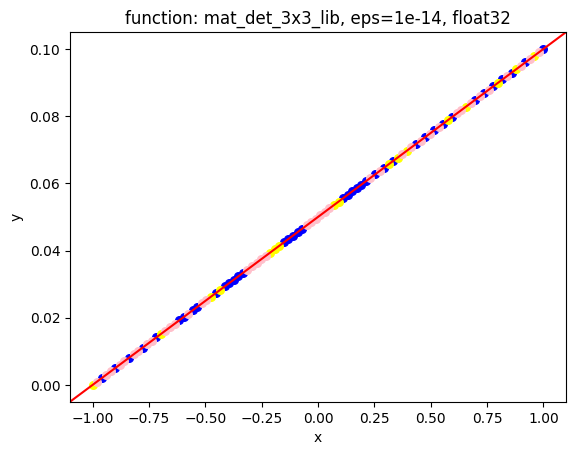

<Figure size 500x500 with 0 Axes>

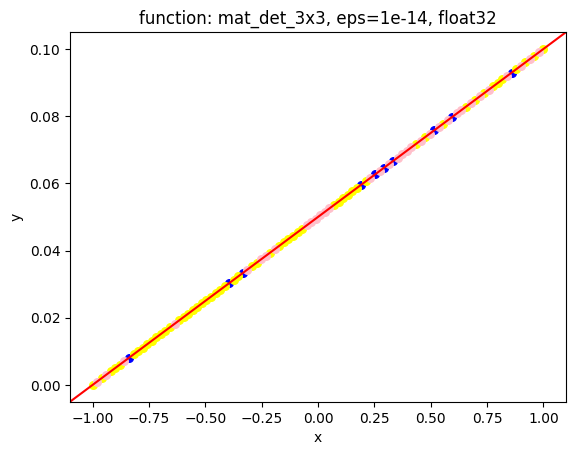

In [38]:
draw(points_d_float32, a, b, epsilons, det_functions)